<a href="https://colab.research.google.com/github/Band3er/course-proj-VR/blob/main/ACV_69170_lab4_part33_totoro4_template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Laboratory Session 4: Diffusion models for computer vision**
**Date:** 2 April 2025
   
**Authors**: Jesús Bermúdez Cameo y Alejandro Pérez Yus

**Version:** 1.0

In this lab session we want to explore the mechanisms behind diffusion models for generating, modifying images and connecting them with computer vision inference.

Goals of the assignment:
1.	Understanding Denoising Diffusion Probabilistic Models (DDPM)
2.	Understanding the Latent diffusion models pipeline
3.	Exploring diffusion model applications like depth estimation
4.  Learn to modify whole images and replace masked objects with text prompts

In [ ]:
!pip install torch==2.6.0+cu124 torchvision==0.21.0 torchaudio==2.6.0 -U xformers==0.0.29.post3 --index-url https://download.pytorch.org/whl/cu124

Looking in indexes: https://download.pytorch.org/whl/cu124
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 110.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 49.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 142.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 5.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 10.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/

In [ ]:
!pip install transformers==4.50.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 93.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 51.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 110.9 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.10.1
    Uninstalling huggingface_hub-1.10.1:
      Successfully uninstalled huggingface_hub-1.10.1
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [ ]:
!pip install torchsde==0.2.6 einops==0.8.1 diffusers==0.32.2 accelerate==1.5.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 122.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 33.6 MB/s eta 0:00:00
  Attempting uninstall: diffusers
    Found existing installation: diffusers 0.35.2
    Uninstalling diffusers-0.35.2:
      Successfully uninstalled diffusers-0.35.2
  Attempting uninstall: accelerate
    Found existing installation: accelerate 1.12.0
    Uninstalling accelerate-1.12.0:
      Successfully uninstalled accelerate-1.12.0


In [ ]:
%cd /content
!git clone -b totoro4 https://github.com/camenduru/ComfyUI /content/ComfyUI
%cd /content/ComfyUI

!apt -y install -qq aria2

!aria2c --console-log-level=error -c -x 16 -s 16 -k 1M https://huggingface.co/camenduru/FLUX.1-dev/resolve/main/flux1-dev-fp8.safetensors -d /content/ComfyUI/models/unet -o flux1-dev-fp8.safetensors
!aria2c --console-log-level=error -c -x 16 -s 16 -k 1M https://huggingface.co/camenduru/FLUX.1-dev/resolve/main/ae.sft -d /content/ComfyUI/models/vae -o ae.sft
!aria2c --console-log-level=error -c -x 16 -s 16 -k 1M https://huggingface.co/camenduru/FLUX.1-dev/resolve/main/clip_l.safetensors -d /content/ComfyUI/models/clip -o clip_l.safetensors
!aria2c --console-log-level=error -c -x 16 -s 16 -k 1M https://huggingface.co/camenduru/FLUX.1-dev/resolve/main/t5xxl_fp8_e4m3fn.safetensors -d /content/ComfyUI/models/clip -o t5xxl_fp8_e4m3fn.safetensors


/content
Cloning into '/content/ComfyUI'...
remote: Enumerating objects: 14652, done.
remote: Total 14652 (delta 0), reused 0 (delta 0), pack-reused 14652 (from 1)
Receiving objects: 100% (14652/14652), 21.12 MiB | 15.25 MiB/s, done.
Resolving deltas: 100% (9825/9825), done.
/content/ComfyUI
The following additional packages will be installed:
  libaria2-0 libc-ares2
The following NEW packages will be installed:
  aria2 libaria2-0 libc-ares2
0 upgraded, 3 newly installed, 0 to remove and 30 not upgraded.
Need to get 1,513 kB of archives.
After this operation, 5,441 kB of additional disk space will be used.
Selecting previously unselected package libc-ares2:amd64.
(Reading database ... 126213 files and directories currently installed.)
Preparing to unpack .../libc-ares2_1.18.1-1ubuntu0.22.04.3_amd64.deb ...
Unpacking libc-ares2:amd64 (1.18.1-1ubuntu0.22.04.3) ...
Selecting previously unselected package libaria2-0:amd64.
Preparing to unpack .../libaria2-0_1.36.0-1_amd64.deb ...
Unpacking

## 3.3 Latent diffusion models for inpainting (Optional)

In this example we are going to use FLUX1.dev model for inpainting.

In [ ]:
import random
import torch
import numpy as np
from PIL import Image
import nodes
from nodes import NODE_CLASS_MAPPINGS
from totoro_extras import nodes_custom_sampler
from totoro import model_management


In [ ]:
from totoro_extras import nodes_differential_diffusion

In [ ]:
from totoro_extras import nodes_flux

In this case we are going to use a module expecialized for inpainting `InpainingModelConditioning` and the `DifferentialDiffusionModule` (https://differential-diffusion.github.io/) which takes into account not only logical maks but also weighted masks to balance the transitions in the inpainting.

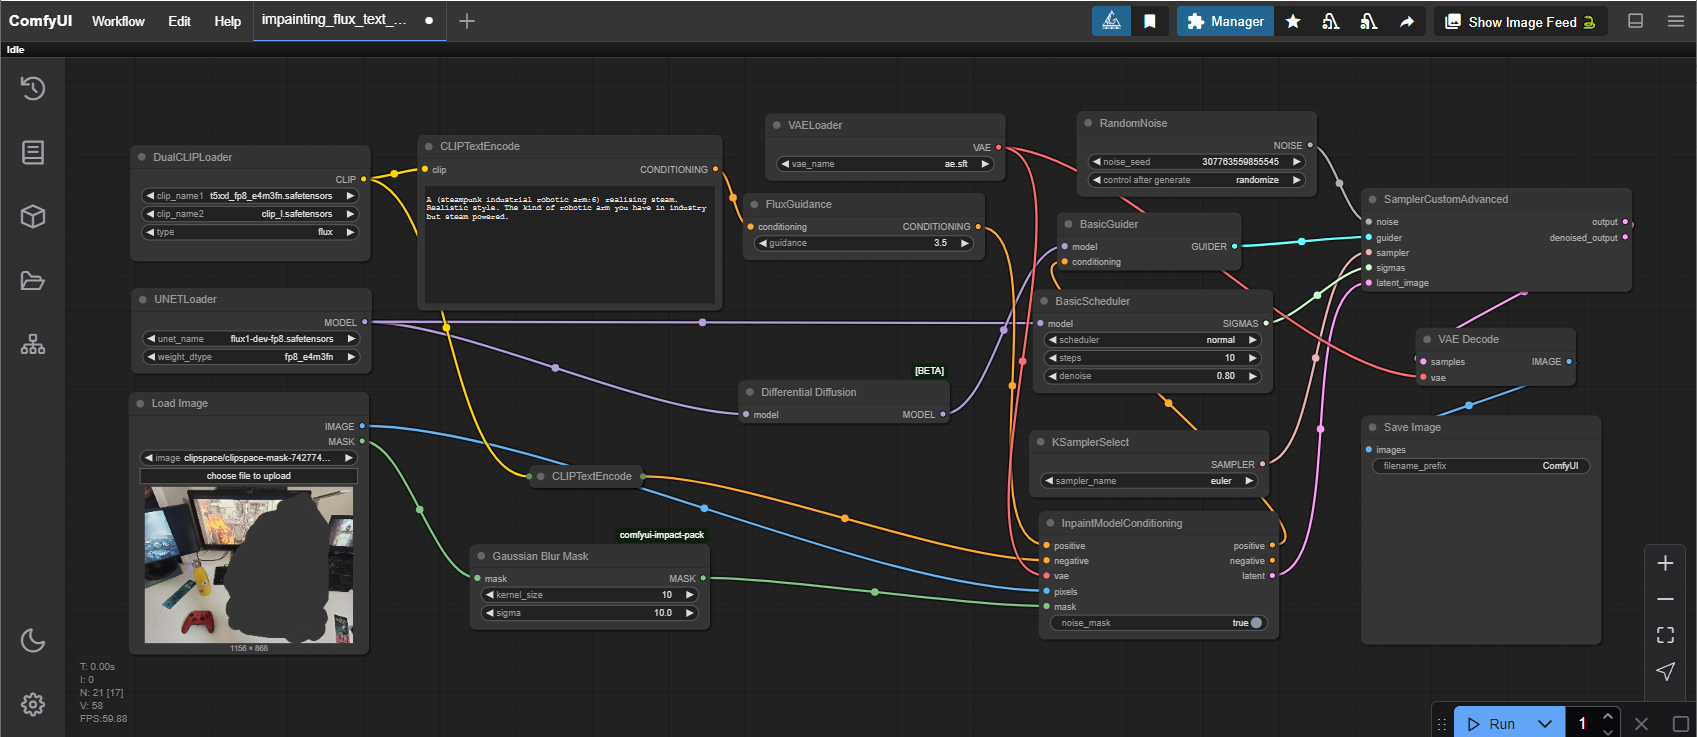

In [ ]:
DualCLIPLoader = NODE_CLASS_MAPPINGS["DualCLIPLoader"]()
UNETLoader = NODE_CLASS_MAPPINGS["UNETLoader"]()
RandomNoise = nodes_custom_sampler.NODE_CLASS_MAPPINGS["RandomNoise"]()
BasicGuider = nodes_custom_sampler.NODE_CLASS_MAPPINGS["BasicGuider"]()
KSamplerSelect = nodes_custom_sampler.NODE_CLASS_MAPPINGS["KSamplerSelect"]() #sampling/custom_sampling
BasicScheduler = nodes_custom_sampler.NODE_CLASS_MAPPINGS["BasicScheduler"]()
SamplerCustomAdvanced = nodes_custom_sampler.NODE_CLASS_MAPPINGS["SamplerCustomAdvanced"]()
VAELoader = NODE_CLASS_MAPPINGS["VAELoader"]()
VAEEncode = NODE_CLASS_MAPPINGS["VAEEncode"]()
VAEDecode = NODE_CLASS_MAPPINGS["VAEDecode"]()
EmptyLatentImage = NODE_CLASS_MAPPINGS["EmptyLatentImage"]()

FluxGuidance = nodes_flux.NODE_CLASS_MAPPINGS["FluxGuidance"]()  #advanced/conditioning/flux

DifferentialDiffusion = nodes_differential_diffusion.NODE_CLASS_MAPPINGS["DifferentialDiffusion"]()

InpaintModelConditioning = NODE_CLASS_MAPPINGS["InpaintModelConditioning"]()  #conditioning/inpaint

LoadImageMask = NODE_CLASS_MAPPINGS["LoadImageMask"]()   # NO USAR

CLIPTextEncode = NODE_CLASS_MAPPINGS["CLIPTextEncode"]()

In [ ]:
with torch.inference_mode():
    unet = UNETLoader.load_unet("flux1-dev-fp8.safetensors", "fp8_e4m3fn")[0]

In [ ]:
with torch.inference_mode():
    vae = VAELoader.load_vae("ae.sft")[0]

In [ ]:
with torch.inference_mode():
    clip = DualCLIPLoader.load_clip("t5xxl_fp8_e4m3fn.safetensors", "clip_l.safetensors", "flux")[0]

In [ ]:
import random
import torch
import numpy as np
from PIL import Image

import matplotlib.pyplot as plt

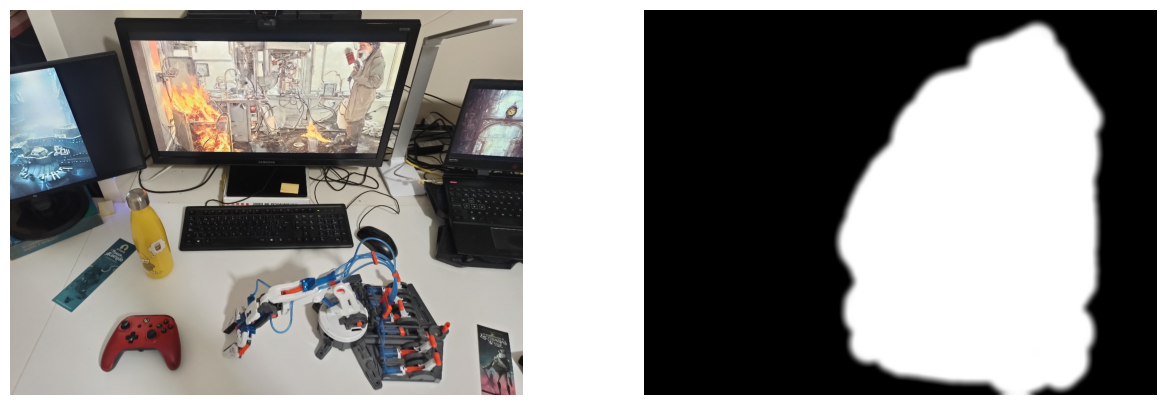

In [ ]:
img_pil = Image.open('/content/IMG_20250308_194103.jpg')
mask_pil = Image.open('/content/mask.png').convert("RGB")

img_in = np.array(img_pil).astype(np.float32) / 255.0
img_in = torch.from_numpy(img_in)[None,]

mask_in = np.array(mask_pil).astype(np.float32) / 255.0
mask_in = torch.from_numpy(mask_in)[None,:,:,0]

[fig,axis] = plt.subplots(1,2,figsize=(15,5))
axis[0].imshow(img_in[0,:,:,:]) #[1,h,w,3] tensor
axis[0].axis('off')
axis[1].imshow(mask_in[0,:,:],cmap='gray') #[1,h,w] tensor
axis[1].axis('off')
plt.show()



In [ ]:
positive_prompt = 'A steampunk industrial robotic arm realising steam. Realistic style. The kind of robotic arm you have in industry but steam powered.'
seed = 0
steps = 10
sampler_name = "euler"
scheduler = "simple"
denoise = 0.7
if seed == 0:
    seed = random.randint(0, 18446744073709551615)
print(seed)

13226632097076368020


In [ ]:
with torch.inference_mode():
    cond, pooled = clip.encode_from_tokens(clip.tokenize(positive_prompt), return_pooled=True)
    cond = [[cond, {"pooled_output": pooled}]]

**Task:** Include the `FluxGuidance` module in particular calling the `FluxGuidance.append` method with inputs `conditioning=cond` and the parameter `guidance`.

In [ ]:
with torch.inference_mode():
    negative = CLIPTextEncode.encode(clip,'')[0]

    guidance = 3.5
    # COMPLETE HERE
    #cond_after_guidance = ...
    # END COMPLETE HERE

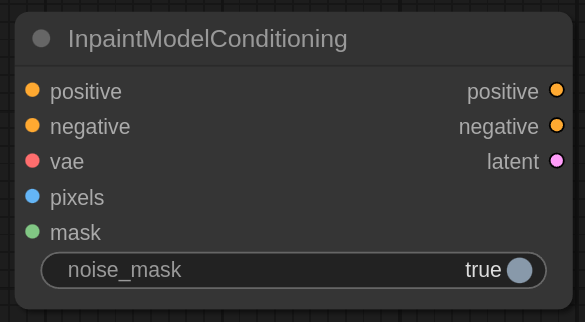

**Task:** Include the InpaintModelConditioning module in particular calling the method `InpaintModelConditioning.encode(positive,negative,pixels,vae,mask)` that returns the tensors `positive`, `negative` and `latent`.

In [ ]:
with torch.inference_mode():
    # COMPLETE HERE
    # positive,negative,latent = ...
    #END COMPLETE HERE

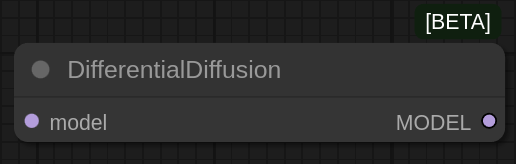

**Task:** Include the differential diffusion model for adapting the Flux1.dev model with the method `DifferentialDiffusion.apply`.

In [ ]:
with torch.inference_mode():
    # COMPLETE HERE
    # guider_unet = ...
    # END COMPLETE HERE

In [ ]:
with torch.inference_mode():
    noise = RandomNoise.get_noise(seed)[0]
    guider = BasicGuider.get_guider(guider_unet, cond)[0]
    sampler = KSamplerSelect.get_sampler(sampler_name)[0]
    sigmas = BasicScheduler.get_sigmas(unet, scheduler, steps, denoise)[0]
    sample, sample_denoised = SamplerCustomAdvanced.sample(noise, guider, sampler, sigmas, latent)
    model_management.soft_empty_cache()
    decoded = VAEDecode.decode(vae, sample)[0].detach()

  0%|          | 0/10 [00:00<?, ?it/s]

(np.float64(-0.5), np.float64(1151.5), np.float64(863.5), np.float64(-0.5))

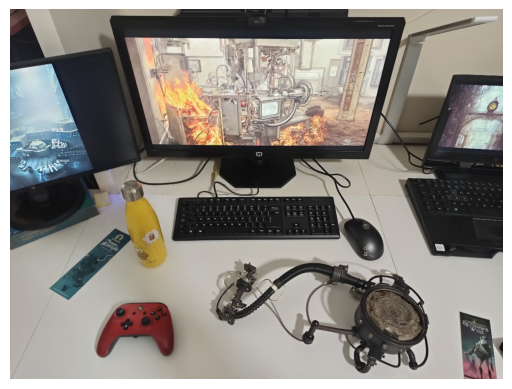

In [ ]:
Image.fromarray(np.array(decoded*255, dtype=np.uint8)[0]).save("./roboti_03.png")
img_out = np.array(decoded*255, dtype=np.uint8)[0]

plt.imshow(img_out)
plt.axis('off')